# HD-Correlated GWB Likelihood Demo

This notebook demonstrates JaxPINT's **correlated PTA likelihood** — a
two-tier Woodbury scheme that accounts for inter-pulsar correlations via
the Hellings-Downs overlap reduction function (ORF).

We compare three likelihood formulations:
1. **No GWB** — per-pulsar noise only
2. **CURN** — uncorrelated common red noise (same PSD, independent pulsars)
3. **HD-correlated GWB** — Hellings-Downs inter-pulsar correlations

All three use realistic synthetic pulsars with white noise, ECORR, and
intrinsic power-law red noise.

In [ ]:
from __future__ import annotations

from io import StringIO

from loguru import logger
logger.disable("pint")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.types import GlobalParams
from jaxpint.pta.signals.gwb import CURNInjector
from jaxpint.pta.signals.correlated_gwb import HDCorrelatedGWBInjector
from jaxpint.pta.signals.orf import hd_orf
from jaxpint.notebook_utils import (
    generate_irregular_mjds,
    generate_random_par,
    plot_1d_delta_logL,
    plot_2d_delta_logL,
    pulsar_positions_from_models,
    random_obs_window,
    setup_synthetic_pta,
    sweep_1d_logL,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
N_TOAS = 200
GLOBAL_START_MJD = 55000.0
GLOBAL_END_MJD = 61000.0
MIN_SPAN_DAYS = 1500.0
TOA_ERROR = 1e-8        # 10 ns
FREQ = 1400.0           # MHz
SEED = 42

# GWB parameters (NANOGrav 15yr)
GWB_LOG10_A = -14.6
GWB_GAMMA = 13.0 / 3.0
GWB_N_COMPONENTS = 14


## Generate synthetic pulsars with realistic noise

Each pulsar has its own sky position, spindown, and noise parameters
(EFAC, EQUAD, ECORR, power-law red noise).

In [ ]:
rng = np.random.default_rng(SEED)

obs_windows = [
    random_obs_window(
        rng,
        global_start_mjd=GLOBAL_START_MJD,
        global_end_mjd=GLOBAL_END_MJD,
        min_span_days=MIN_SPAN_DAYS,
    )
    for _ in range(N_PULSARS)
]
par_strings = [
    generate_random_par(idx, rng, start_mjd=s, noise="realistic", include_dm=True)
    for idx, (s, _) in enumerate(obs_windows)
]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

mjds_per_pulsar = [
    generate_irregular_mjds(rng, start_mjd=s, end_mjd=e, n_approx=N_TOAS)
    for (s, e) in obs_windows
]

synthetic = setup_synthetic_pta(
    pint_models,
    toa_error_s=TOA_ERROR, freq_mhz=FREQ,
    mjds_per_pulsar=mjds_per_pulsar,
)
toa_data_list = list(synthetic.toa_data_list)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
pp_tuple = synthetic.pulsar_params_list

# Pulsar unit vectors for HD injector
positions = pulsar_positions_from_models(pint_models)

T_span_s = (GLOBAL_END_MJD - GLOBAL_START_MJD) * 86400.0

print(f"Generated {N_PULSARS} pulsars with Poisson-cadence TOAs.")
for i, (s, e) in enumerate(obs_windows):
    print(f"  Pulsar {i}: {pint_models[i].PSR.value:>20s}  n_toas={toa_data_list[i].n_toas:3d}  "
          f"MJD {s:.0f}–{e:.0f}")


## Visualize the Hellings-Downs ORF matrix

The HD ORF encodes inter-pulsar correlations as a function of angular
separation. The diagonal is ~0.5 (auto-correlation); off-diagonal values
range from roughly -0.15 to +0.5.

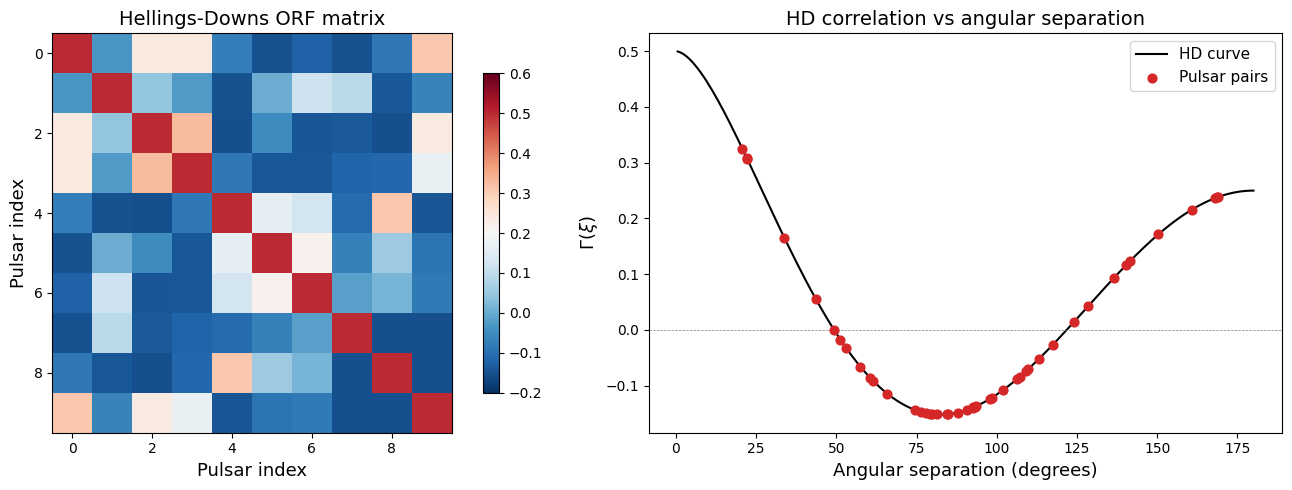

In [3]:
# Build the HD-correlated GWB injector
hd_gwb = HDCorrelatedGWBInjector(
    pulsar_positions=positions,
    n_components=GWB_N_COMPONENTS,
    T_span=T_span_s,
    orf_func=hd_orf,
    initial_values={"log10_A": GWB_LOG10_A, "gamma": GWB_GAMMA},
)

Gamma = np.array(hd_gwb.get_orf_matrix())

# Angular separations for the HD curve
xi_grid = np.linspace(0.01, np.pi, 200)
x_grid = (1 - np.cos(xi_grid)) / 2
hd_curve = 1.5 * x_grid * np.log(x_grid) - 0.25 * x_grid + 0.5

# Compute angular separations for each pulsar pair
pos_np = np.array(positions)
pair_angles = []
pair_gammas = []
for a in range(N_PULSARS):
    for b in range(a + 1, N_PULSARS):
        cos_xi = np.dot(pos_np[a], pos_np[b])
        pair_angles.append(np.arccos(np.clip(cos_xi, -1, 1)))
        pair_gammas.append(Gamma[a, b])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ORF matrix heatmap
im = axes[0].imshow(Gamma, cmap="RdBu_r", vmin=-0.2, vmax=0.6)
axes[0].set_xlabel("Pulsar index", fontsize=13)
axes[0].set_ylabel("Pulsar index", fontsize=13)
axes[0].set_title("Hellings-Downs ORF matrix", fontsize=14)
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Right: HD curve with pulsar pair values
axes[1].plot(np.degrees(xi_grid), hd_curve, "k-", linewidth=1.5, label="HD curve")
axes[1].scatter(np.degrees(pair_angles), pair_gammas, c="tab:red", s=40,
                zorder=5, label="Pulsar pairs")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[1].set_xlabel("Angular separation (degrees)", fontsize=13)
axes[1].set_ylabel(r"$\Gamma(\xi)$", fontsize=13)
axes[1].set_title("HD correlation vs angular separation", fontsize=14)
axes[1].legend(fontsize=11)

fig.tight_layout()
plt.show()

## Set up three likelihood configurations

All three call the same `pta_logL`; the difference is what's in the `PTAConfig`:

1. **No GWB**: `signal_injectors=()`, `correlated_injectors=()`
2. **CURN**: `signal_injectors=(curn,)`, `correlated_injectors=()` (uncorrelated common red noise)
3. **HD-correlated**: `signal_injectors=()`, `correlated_injectors=(hd_gwb,)` (cross-pulsar coupling via Hellings-Downs)

In [ ]:
# 1. No GWB
config_none = PTAConfig(
    toa_data_list=tuple(toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(),
)
gp_none = GlobalParams.empty()

# 2. CURN (uncorrelated common red noise)
curn = CURNInjector(
    n_components=GWB_N_COMPONENTS,
    T_span=T_span_s,
    initial_values={"log10_A": GWB_LOG10_A, "gamma": GWB_GAMMA},
)
gp_curn = curn.register_params(GlobalParams.empty())

config_curn = PTAConfig(
    toa_data_list=tuple(toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(curn,),
)

# 3. HD-correlated GWB (hd_gwb already created above)
gp_hd = hd_gwb.register_params(GlobalParams.empty())

config_hd = PTAConfig(
    toa_data_list=tuple(toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(),
    correlated_injectors=(hd_gwb,),
)

print("Configurations ready:")
print(f"  No GWB:       {gp_none.n_params} global params")
print(f"  CURN:         {gp_curn.n_params} global params ({gp_curn.names})")
print(f"  HD-correlated: {gp_hd.n_params} global params ({gp_hd.names})")

## Evaluate likelihoods at the true parameters

Quick sanity check: all three should produce finite log-likelihood values.

In [ ]:
logL_none = float(pta_logL(gp_none, pp_tuple, config_none))
logL_curn = float(pta_logL(gp_curn, pp_tuple, config_curn))
logL_hd = float(pta_logL(gp_hd, pp_tuple, config_hd))

print(f"Log-likelihood at true parameters:")
print(f"  No GWB:        {logL_none:>20.4f}")
print(f"  CURN:          {logL_curn:>20.4f}")
print(f"  HD-correlated: {logL_hd:>20.4f}")
print(f"\n  CURN - No GWB: {logL_curn - logL_none:>+20.4f}")
print(f"  HD   - CURN:   {logL_hd - logL_curn:>+20.4f}")

## Sweep GWB amplitude: CURN vs HD-correlated

Sweep `log10_A` while holding `gamma` fixed. This shows how the two
likelihood formulations respond differently to GWB amplitude.

In [ ]:
log10_A_grid = np.linspace(-16.0, -13.0, 80)


def curn_logL_at_A(log10_A):
    gp = gp_curn.with_value("gwb_log10_A", log10_A)
    return pta_logL(gp, pp_tuple, config_curn)


def hd_logL_at_A(log10_A):
    gp = gp_hd.with_value("gwb_log10_A", log10_A)
    return pta_logL(gp, pp_tuple, config_hd)


print("Sweeping log10_A...")
logL_curn_sweep = sweep_1d_logL(curn_logL_at_A, log10_A_grid)
logL_hd_sweep = sweep_1d_logL(hd_logL_at_A, log10_A_grid)
print("Done.")


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_1d_delta_logL(
    ax, log10_A_grid, logL_curn_sweep,
    label="CURN (uncorrelated)", linewidth=2,
)
plot_1d_delta_logL(
    ax, log10_A_grid, logL_hd_sweep,
    true_value=GWB_LOG10_A,
    label="HD-correlated GWB",
    xlabel=r"$\log_{10} A$",
    linewidth=2,
)

ax.set_title(
    f"GWB amplitude sweep ($\\gamma$ = {GWB_GAMMA:.2f} fixed, "
    f"{N_PULSARS} pulsars, {GWB_N_COMPONENTS} Fourier components)",
    fontsize=14,
)
ax.set_yscale("symlog", linthresh=10)
ax.legend(fontsize=12)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()

## 2D likelihood surface: log10_A vs gamma

Sweep both GWB parameters to visualize the joint likelihood surface
under the HD-correlated model.

In [ ]:
A_grid = np.linspace(-16.0, -13.5, 40)
gamma_grid = np.linspace(2.0, 7.0, 40)


def hd_logL_at_A_gamma(log10_A, gamma):
    gp = gp_hd.with_value("gwb_log10_A", log10_A)
    gp = gp.with_value("gwb_gamma", gamma)
    return pta_logL(gp, pp_tuple, config_hd)


print("Computing 2D HD likelihood surface...")
logL_2d = sweep_2d_logL(hd_logL_at_A_gamma, A_grid, gamma_grid)
print("Done.")


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

mesh = plot_2d_delta_logL(
    ax, A_grid, gamma_grid, logL_2d,
    true_xy=(GWB_LOG10_A, GWB_GAMMA),
    clip_min=-500.0,
)

ax.set_xlabel(r"$\log_{10} A$", fontsize=13)
ax.set_ylabel(r"$\gamma$", fontsize=13)
ax.set_title("HD-correlated GWB likelihood surface", fontsize=14)
ax.legend(fontsize=12, loc="upper left")
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## Difference between CURN and HD-correlated likelihoods

The difference `logL_HD - logL_CURN` isolates the effect of inter-pulsar
correlations. This is analogous to what the optimal statistic measures.

In [ ]:
def curn_logL_at_A_gamma(log10_A, gamma):
    gp = gp_curn.with_value("gwb_log10_A", log10_A)
    gp = gp.with_value("gwb_gamma", gamma)
    return pta_logL(gp, pp_tuple, config_curn)


print("Computing CURN 2D surface...")
logL_curn_2d = sweep_2d_logL(curn_logL_at_A_gamma, A_grid, gamma_grid)
print("Done.")

diff_2d = logL_2d - logL_curn_2d

fig, ax = plt.subplots(figsize=(10, 7))
vmax = max(abs(diff_2d.min()), abs(diff_2d.max()))
cf = ax.contourf(A_grid, gamma_grid, diff_2d, levels=30, cmap="RdBu_r",
                 vmin=-vmax, vmax=vmax)
ax.plot(GWB_LOG10_A, GWB_GAMMA, "k*", markersize=15, label="True values")
ax.set_xlabel(r"$\log_{10} A$", fontsize=13)
ax.set_ylabel(r"$\gamma$", fontsize=13)
ax.set_title(r"$\log\mathcal{L}_\mathrm{HD} - \log\mathcal{L}_\mathrm{CURN}$"
             " (effect of inter-pulsar correlations)", fontsize=14)
ax.legend(fontsize=12)
fig.colorbar(cf, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()
